In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv(r'C:/Users/suhan/OneDrive/Desktop/Practicals_1/Max-min-Ahmedabad.csv')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime
import seaborn as sns
# from colorsetup import colors, palette
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
import scipy.stats as stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm
from scipy.optimize import minimize_scalar
from sklearn.preprocessing import PowerTransformer


In [3]:
data['Date'] = pd.to_datetime(data[['year', 'month', 'day']])
data.set_index('Date', inplace=True)
print(data.index)
print(type(data.index))


DatetimeIndex(['1970-01-01', '1971-01-01', '1972-01-01', '1973-01-01',
               '1974-01-01', '1975-01-01', '1977-01-01', '1978-01-01',
               '1979-01-01', '1980-01-01',
               ...
               '2012-12-31', '2013-12-31', '2014-12-31', '2015-12-31',
               '2016-12-31', '2017-12-31', '2018-12-31', '2019-12-31',
               '2020-12-31', '2021-12-31'],
              dtype='datetime64[ns]', name='Date', length=19305, freq=None)
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [31]:
import numpy as np
import scipy.stats as stats

# Ensure no zero or negative values before Box-Cox transformation
rainfall_transformed = data['..R/F'] + 0.1  # Offset to handle zero values

# Apply Box-Cox transformation
fitted_data, fitted_lambda = stats.boxcox(rainfall_transformed)
data['..R/F_transformed'] = fitted_data

print(f"Box-Cox transformation lambda: {fitted_lambda:.4f}")


Box-Cox transformation lambda: -1.6131


In [43]:
monthly_data = data.resample('M').mean()
# Ensure no zero or negative values before Box-Cox transformation
rainfall_transformed = monthly_data['..R/F'] + 0.1  # Offset to handle zero values

# Apply Box-Cox transformation
fitted_data, fitted_lambda = stats.boxcox(rainfall_transformed)
monthly_data['..R/F_transformed_monthly'] = fitted_data

print(f"Box-Cox transformation lambda: {fitted_lambda:.4f}")

Box-Cox transformation lambda: -0.3909


C:\Users\suhan\AppData\Local\Temp\ipykernel_13336\3550880328.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = data.resample('M').mean()


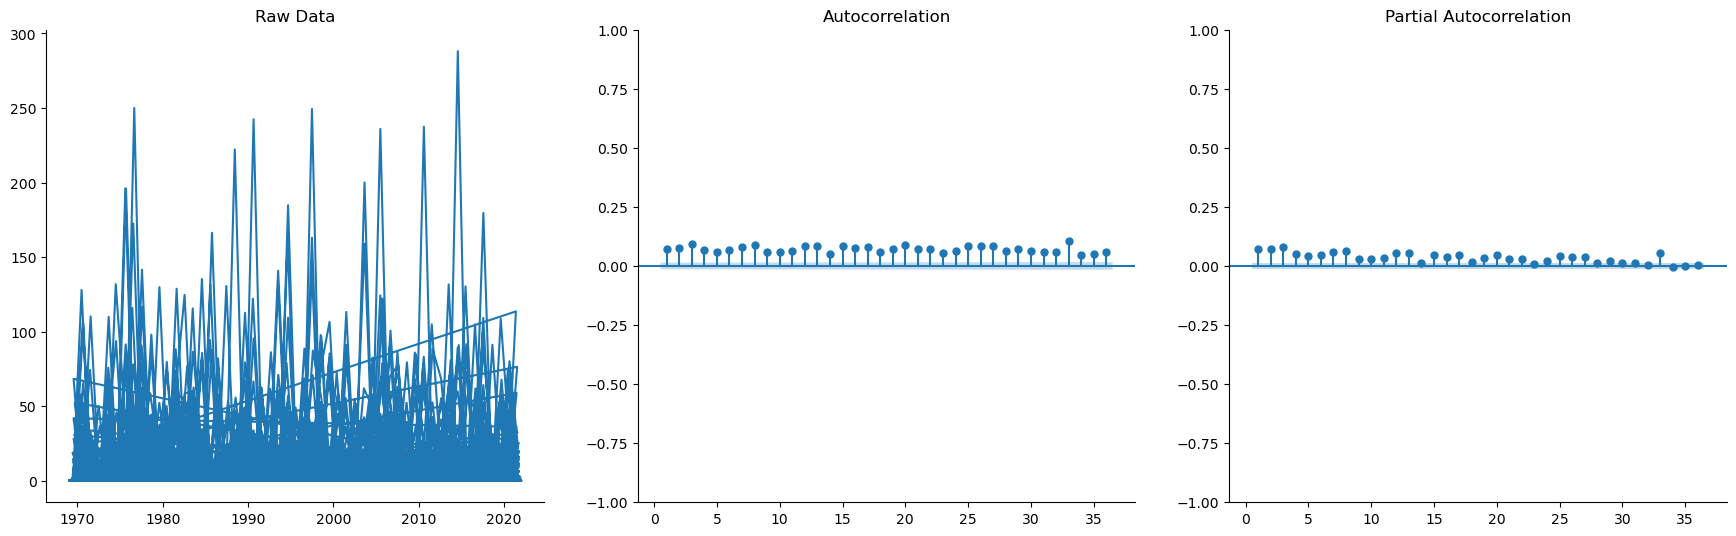

In [37]:


# Define helper plot function for visualization
def plots(data, lags=None):
    plt.figure(figsize=(18, 6))  # Adjust the width and height here
    layout = (1, 3)
    raw  = plt.subplot2grid(layout, (0, 0))
    acf  = plt.subplot2grid(layout, (0, 1))
    pacf = plt.subplot2grid(layout, (0, 2))
    
    # Plot the data and correlation graphs
    raw.plot(data)
    raw.set_title('Raw Data')  # Add title for clarity
    
    sm.tsa.graphics.plot_acf(data, lags=lags, ax=acf, zero=False)
    acf.set_title('Autocorrelation')  # Set title manually
    
    sm.tsa.graphics.plot_pacf(data, lags=lags, ax=pacf, zero=False)
    pacf.set_title('Partial Autocorrelation')  # Set title manually
    
    sns.despine()
    plt.tight_layout(pad=3)  # Add padding between subplots
    plt.show()

# Helper plot for monthly temps
plots(data['..R/F'], lags=36)


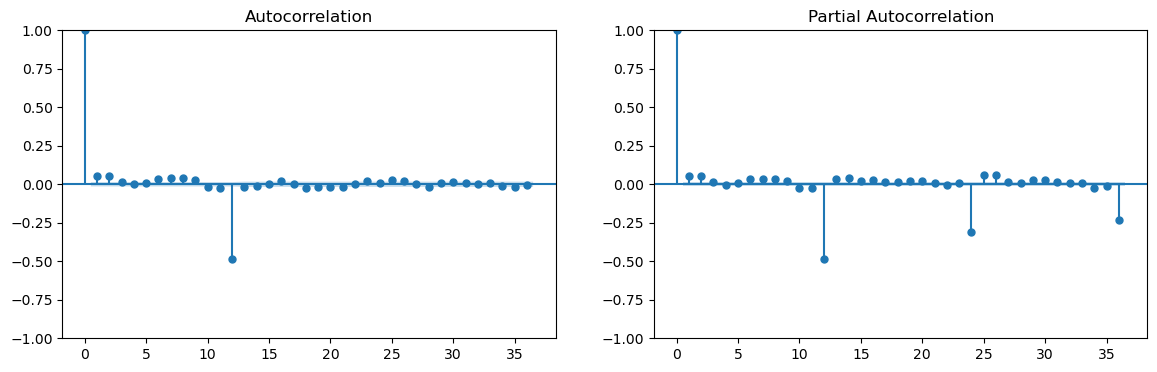

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(data['R/F_transformed'], lags=36, ax=axes[0])
plot_pacf(data['R/F_transformed'], lags=36, ax=axes[1])
plt.show()


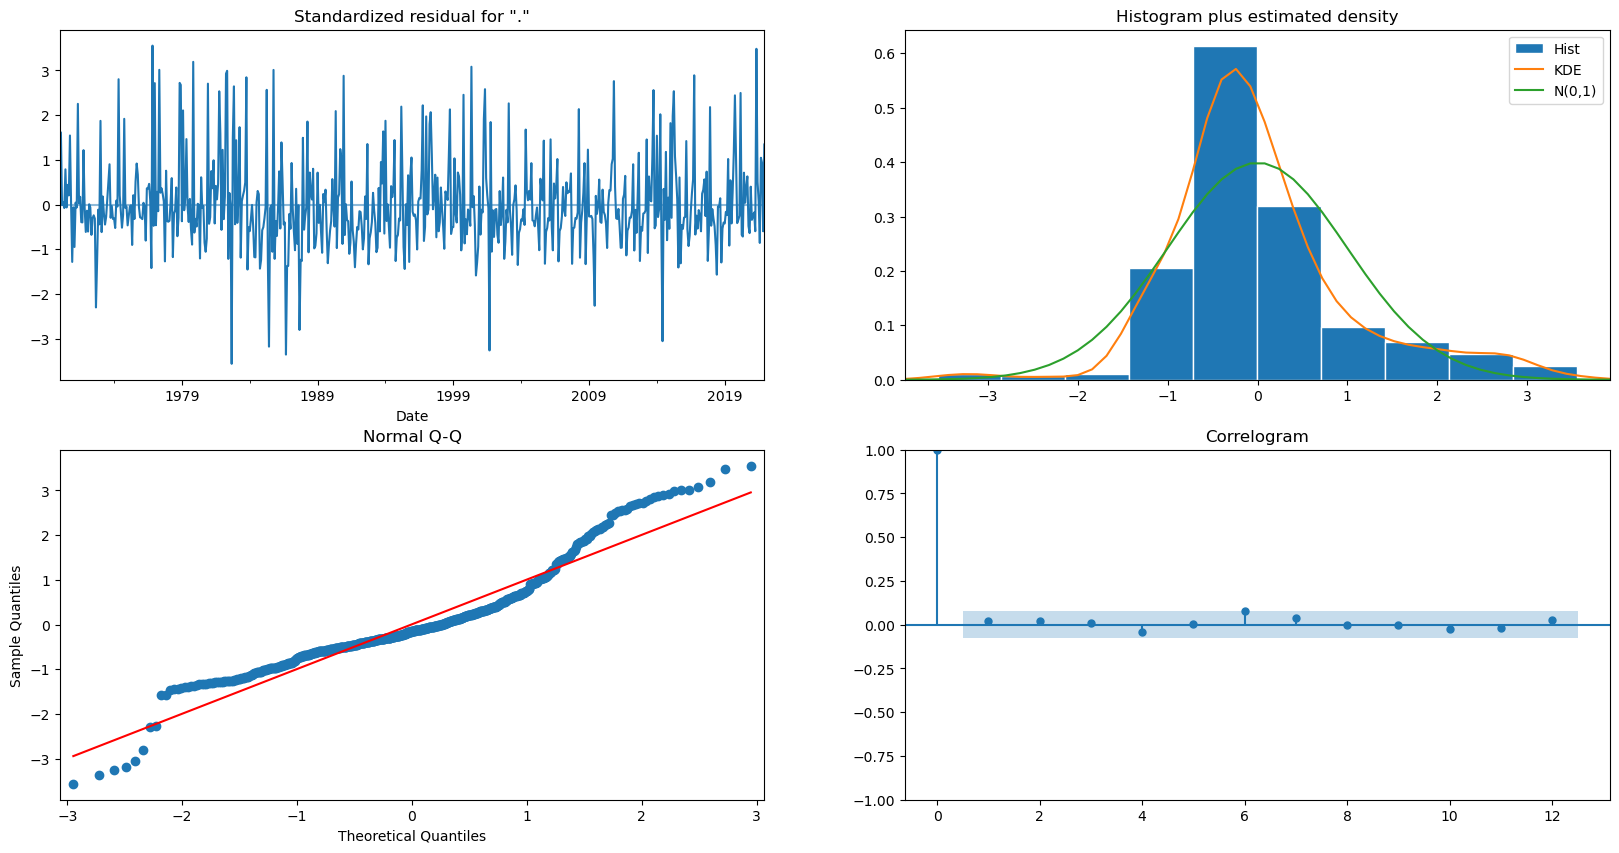

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sar = sm.tsa.statespace.SARIMAX(monthly_data['..R/F_transformed_monthly'],
                                order=(2,0,2), 
                                seasonal_order=(0,1,1,12), 
                                trend='c').fit()
sar.summary()


sar.plot_diagnostics(lags=12,figsize = (20,10),);


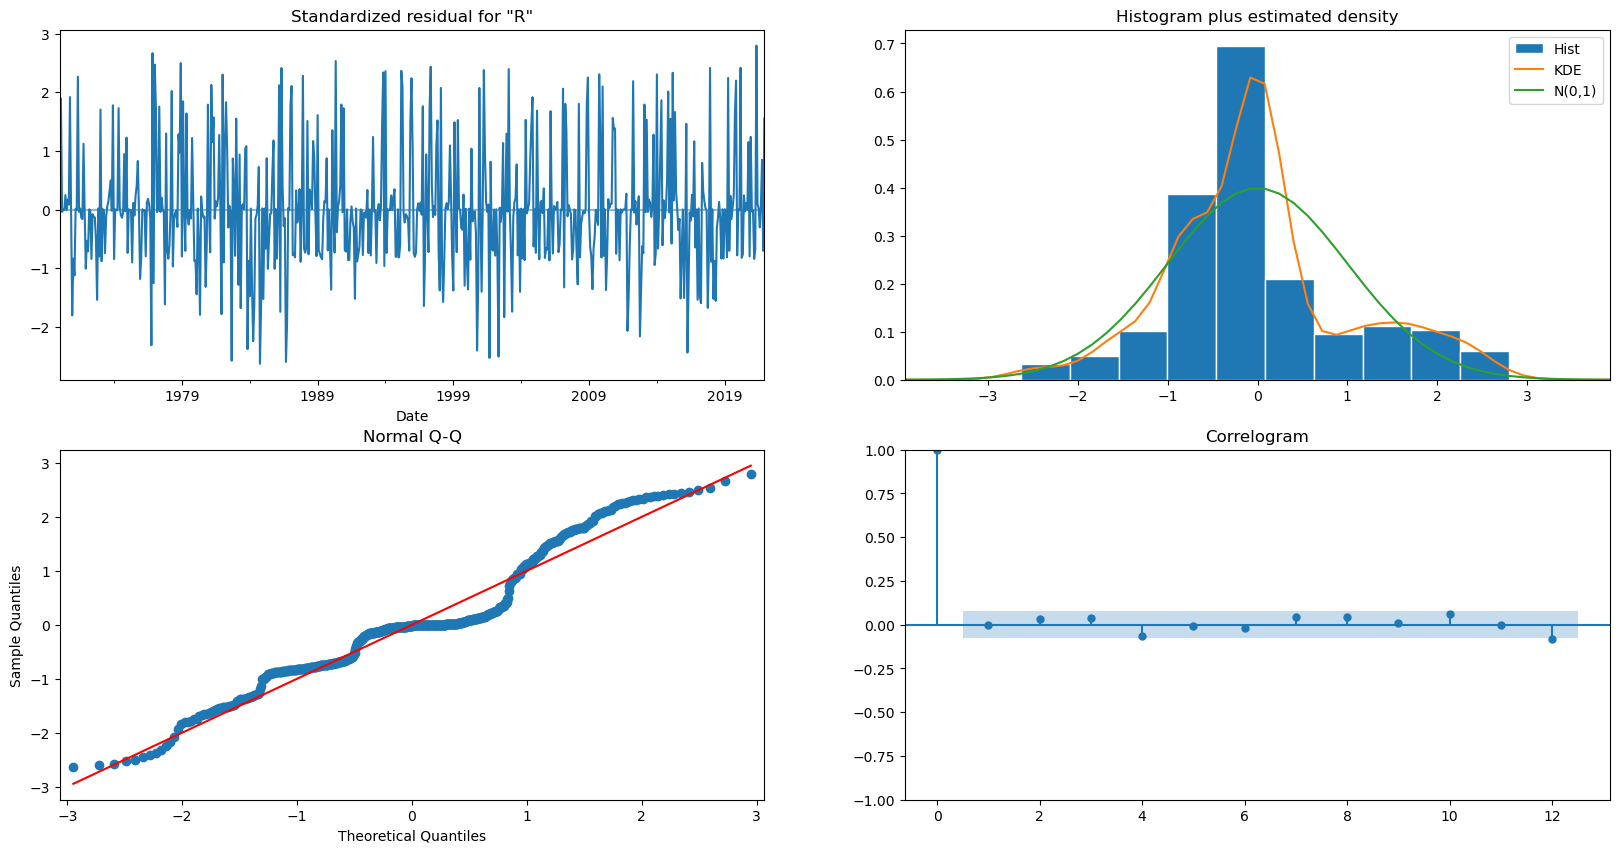

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sar = sm.tsa.statespace.SARIMAX(monthly_data['R/F_transformed'],
                                order=(0,0,1), 
                                seasonal_order=(2,0,0,12), 
                                trend='c').fit()
sar.summary()


sar.plot_diagnostics(lags=12,figsize = (20,10),);


C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\1715410976.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = data['..R/F'].resample('M').sum().to_frame()
C:\Users\suhan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best GBM Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Residual RMSE: 1.184385786950337
Residual R²: -0.17073832323872695
Final RMSE: 1.184385786950337
Final R²: 0.7385714053179961


C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\1715410976.py:107: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start=monthly_df.index[-1] + pd.DateOffset(months=1), periods=future_months, freq='M')
C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\1715410976.py:190: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  observed_yearly = monthly_df['..R/F'].resample('Y').sum()
C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\1715410976.py:191: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecasted_yearly = forecast_series.resample('Y').sum()


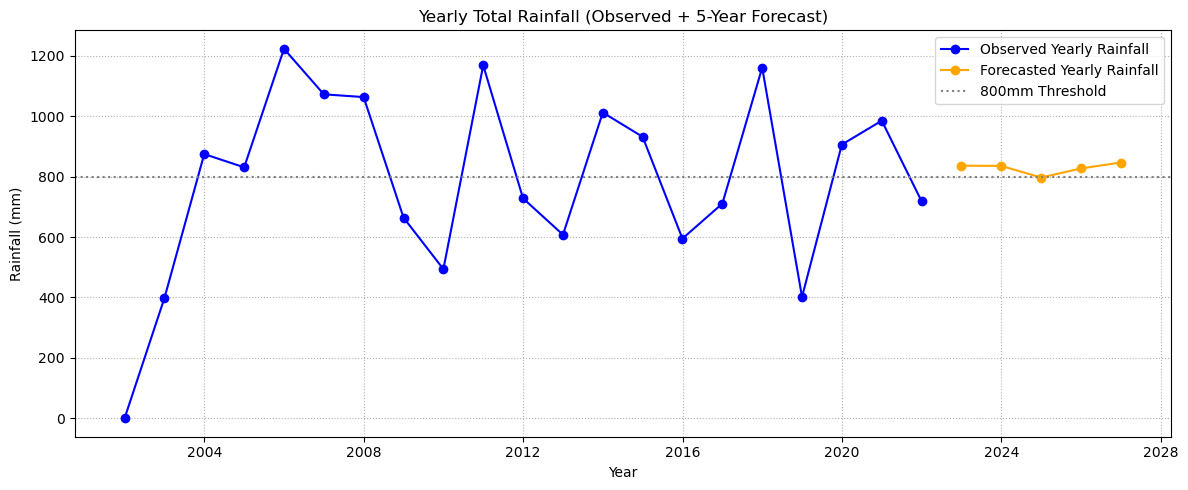

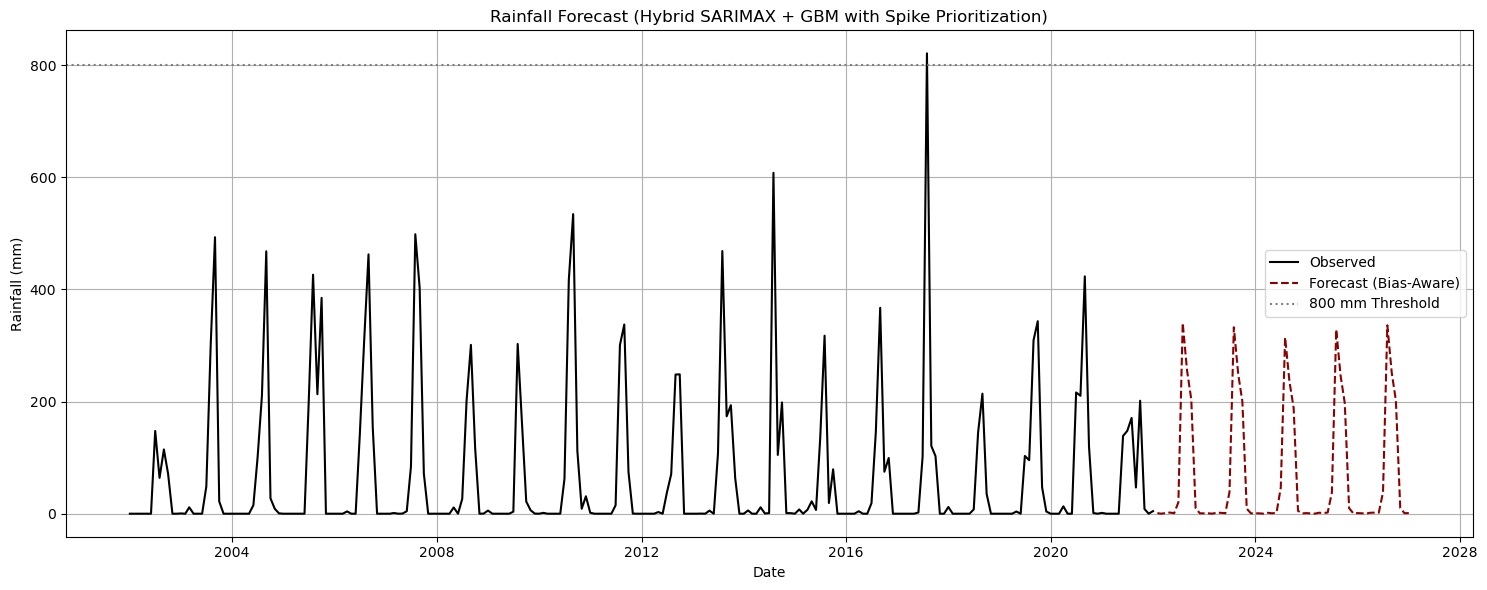

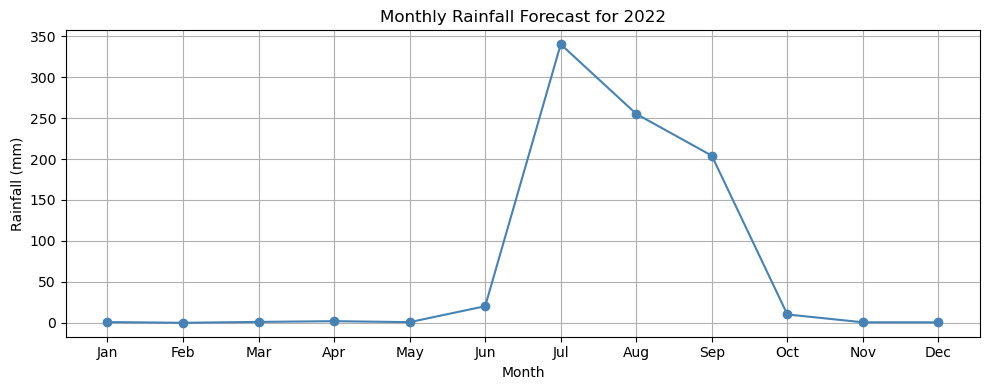

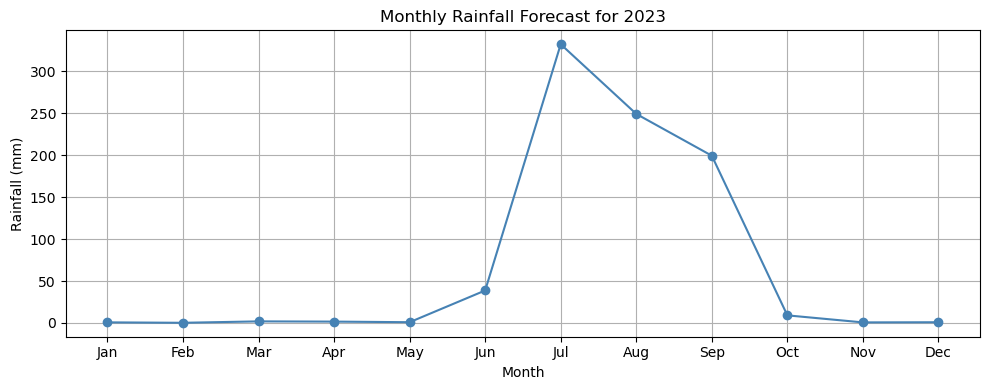

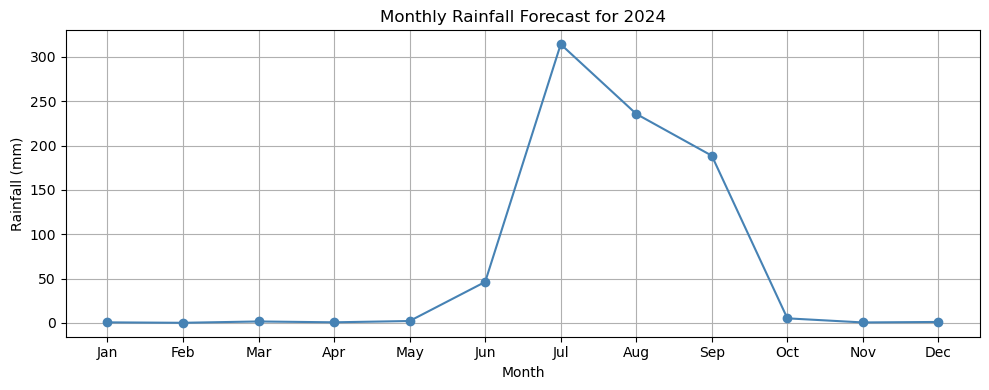

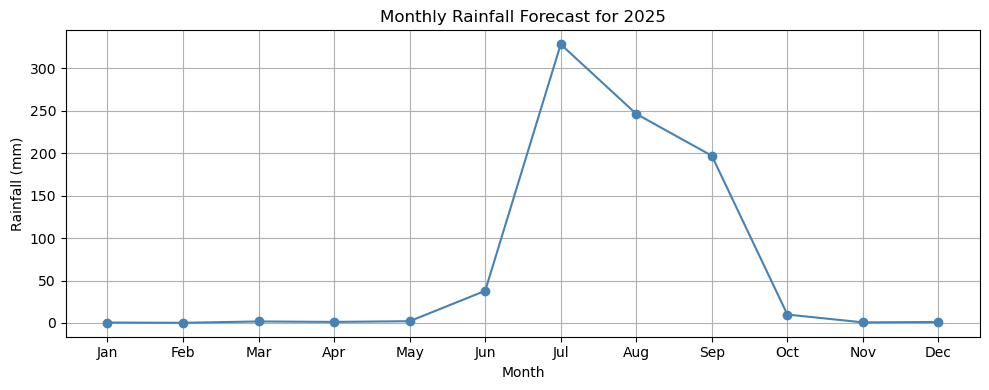

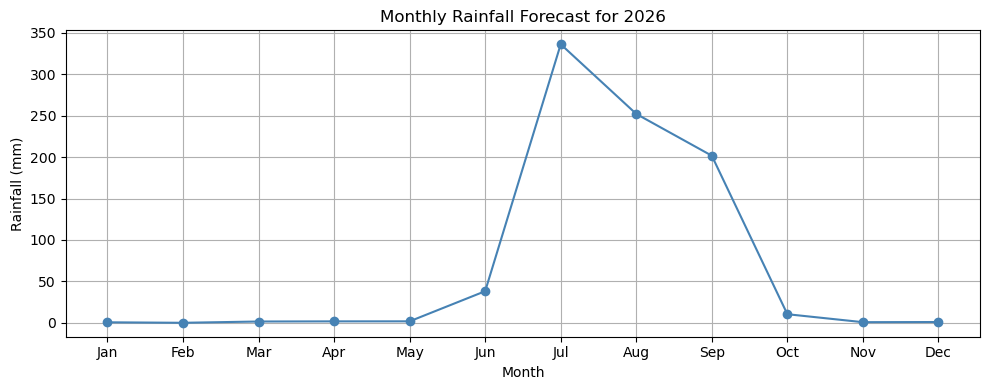


📅 Forecasted Monthly Rainfall (Formatted Table View):

Month and Year  Prediction (mm) Month and Year   Prediction (mm)  Month and Year    Prediction (mm)  
      Jan 2022              1.0        Feb 2022               0.1         Mar 2022                1.2
      Apr 2022              2.1        May 2022               0.9         Jun 2022               20.3
      Jul 2022            340.1        Aug 2022             255.1         Sep 2022              204.1
      Oct 2022             10.2        Nov 2022               0.7         Dec 2022                0.6
      Jan 2023              0.7        Feb 2023               0.1         Mar 2023                1.8
      Apr 2023              1.6        May 2023               0.8         Jun 2023               38.7
      Jul 2023            332.5        Aug 2023             249.4         Sep 2023              199.5
      Oct 2023              9.0        Nov 2023               0.6         Dec 2023                0.8
      Jan 2024            

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Data Preprocessing
# -----------------------------
monthly_df = data['..R/F'].resample('M').sum().to_frame()
monthly_df = monthly_df[monthly_df.index >= monthly_df.index[-1] - pd.DateOffset(years=20)]
monthly_df['..R/F_log'] = np.log1p(monthly_df['..R/F'])

monthwise_avg = monthly_df['..R/F_log'].groupby(monthly_df.index.month).mean()

# -----------------------------
# Fit SARIMAX
# -----------------------------
sarimax_model = SARIMAX(monthly_df['..R/F_log'], order=(2,1,2), seasonal_order=(2,1,1,12))
sarimax_result = sarimax_model.fit(disp=False)
sarimax_fitted = sarimax_result.fittedvalues
residuals = monthly_df['..R/F_log'] - sarimax_fitted
residuals = residuals.dropna()

# -----------------------------
# Define spike bias (manually prioritized)
# -----------------------------
spike_bias = {6: 0.6, 7: 1.0, 8: 0.95, 9: 0.5}
default_bias = 0.2

# -----------------------------
# Feature Engineering
# -----------------------------
def create_rf_features(df, target_col, resid=None):
    df_feat = df.copy()
    for i in range(1, 7):
        df_feat[f'lag_{i}'] = df_feat[target_col].shift(i)
    df_feat['roll_3'] = df_feat[target_col].rolling(3).mean().shift(1)
    df_feat['roll_6'] = df_feat[target_col].rolling(6).mean().shift(1)
    df_feat['month'] = df_feat.index.month
    df_feat['year'] = df_feat.index.year
    df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
    df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)
    df_feat['is_rain_month'] = df_feat['month'].isin([6, 7, 8, 9, 10]).astype(int)
    df_feat['spike_priority_score'] = df_feat['month'].map(lambda x: spike_bias.get(x, default_bias))
    df_feat['seasonal_avg'] = df_feat['month'].map(monthwise_avg)
    df_feat['is_august_boost'] = ((df_feat['month'] == 8) & (df_feat['lag_1'] > df_feat['roll_3'])).astype(int)
    df_feat['resid_lag_12'] = resid.shift(12) if resid is not None else np.nan
    return df_feat.dropna()

rf_features = create_rf_features(monthly_df[['..R/F_log']], '..R/F_log', resid=residuals)
rf_features['residual'] = residuals
rf_features.drop(columns=['..R/F_log'], inplace=True)

# -----------------------------
# Train-Test Split
# -----------------------------
cutoff = monthly_df.index[-1] - pd.DateOffset(years=5)
train_rf = rf_features[rf_features.index <= cutoff]
test_rf = rf_features[rf_features.index > cutoff]

# -----------------------------
# Train GBM
# -----------------------------
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [300, 400, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.025, 0.05],
    'subsample': [0.6, 0.8, 1.0]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(train_rf.drop(['residual'], axis=1), train_rf['residual'])
gbm = grid_search.best_estimator_
print("Best GBM Params:", grid_search.best_params_)
gbm.fit(train_rf.drop(['residual'], axis=1), train_rf['residual'])

# -----------------------------
# Evaluation
# -----------------------------
residual_preds = gbm.predict(test_rf.drop(['residual'], axis=1))
true_residuals = test_rf['residual']
print("Residual RMSE:", np.sqrt(mean_squared_error(true_residuals, residual_preds)))
print("Residual R²:", r2_score(true_residuals, residual_preds))

sarimax_test_pred = sarimax_fitted[test_rf.index]
final_log_pred = sarimax_test_pred + residual_preds
final_log_actual = monthly_df['..R/F_log'].loc[test_rf.index]
print("Final RMSE:", np.sqrt(mean_squared_error(final_log_actual, final_log_pred)))
print("Final R²:", r2_score(final_log_actual, final_log_pred))

# -----------------------------
# Forecasting
# -----------------------------
future_months = 60
forecast_dates = pd.date_range(start=monthly_df.index[-1] + pd.DateOffset(months=1), periods=future_months, freq='M')
sarimax_baseline = sarimax_result.get_forecast(steps=future_months).predicted_mean
sarimax_baseline.index = forecast_dates

history_df = monthly_df.copy()
combined_forecast = []
feature_cols = train_rf.drop(['residual'], axis=1).columns.tolist()
prev_august_val = 0

prev_july_val = None
prev_august_val = None

for date in forecast_dates:
    lags = history_df['..R/F_log'].iloc[-6:].values[::-1]
    roll_3 = history_df['..R/F_log'].iloc[-3:].mean()
    roll_6 = history_df['..R/F_log'].iloc[-6:].mean()
    month = date.month
    year = date.year
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)
    spike_priority_score = spike_bias.get(month, default_bias)
    seasonal_avg = monthwise_avg.get(month, 0)
    resid_lag_12 = residuals.shift(12).iloc[-1] if len(residuals) >= 12 else 0
    is_rain_month = int(month in [6, 7, 8, 9, 10])
    is_august_boost = int((month == 8) and (lags[0] > roll_3))

    rf_input = {f'lag_{i+1}': lags[i] for i in range(6)}
    rf_input.update({
        'roll_3': roll_3,
        'roll_6': roll_6,
        'month': month,
        'year': year,
        'month_sin': month_sin,
        'month_cos': month_cos,
        'spike_priority_score': spike_priority_score,
        'seasonal_avg': seasonal_avg,
        'resid_lag_12': resid_lag_12,
        'is_rain_month': is_rain_month,
        'is_august_boost': is_august_boost
    })

    rf_input_df = pd.DataFrame([rf_input], index=[date])
    rf_input_df = rf_input_df[feature_cols]
    correction = gbm.predict(rf_input_df)[0]

    if month in [6, 8]:
        correction += np.random.normal(0.01, 0.025)

    corrected_log = sarimax_baseline.loc[date] + correction
    corrected = max(0, np.expm1(corrected_log))

    if month == 8 and prev_july_val is not None:
        min_august = prev_july_val * 0.75
        corrected = max(corrected, min_august)

    if month == 9 and prev_august_val is not None:
        min_sept = prev_august_val * 0.7
        corrected = max(corrected, min_sept)
    if month == 9 and prev_july_val is not None:
        corrected = max(corrected, prev_july_val * 0.6)

    if month == 7:
        prev_july_val = corrected
    if month == 8:
        prev_august_val = corrected

    combined_forecast.append(corrected)
    history_df.loc[date] = np.nan
    history_df.loc[date, '..R/F_log'] = np.log1p(corrected)



forecast_series = pd.Series(combined_forecast, index=forecast_dates)

last_obs_year = monthly_df.index[-1].year
forecast_years = forecast_series.index.year.unique()

# Compute yearly rainfall
observed_yearly = monthly_df['..R/F'].resample('Y').sum()
forecasted_yearly = forecast_series.resample('Y').sum()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(observed_yearly.index, observed_yearly.values, label='Observed Yearly Rainfall', color='blue', marker='o')
plt.plot(forecasted_yearly.index, forecasted_yearly.values, label='Forecasted Yearly Rainfall', color='orange', marker='o')
plt.axhline(800, color='gray', linestyle=':', label='800mm Threshold')
plt.title("Yearly Total Rainfall (Observed + 5-Year Forecast)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

# -----------------------------
# Plot Main Forecast
# -----------------------------
plt.figure(figsize=(15, 6))
plt.plot(monthly_df.index, monthly_df['..R/F'], label='Observed', color='black')
plt.plot(forecast_series.index, forecast_series, label='Forecast (Bias-Aware)', color='darkred', linestyle='--')
plt.axhline(800, color='gray', linestyle=':', label='800 mm Threshold')
plt.title("Rainfall Forecast (Hybrid SARIMAX + GBM with Spike Prioritization)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot Year-Wise Monthly Forecasts
# -----------------------------
for year in forecast_series.index.year.unique():
    subset = forecast_series[forecast_series.index.year == year]
    plt.figure(figsize=(10, 4))
    plt.plot(subset.index.month, subset.values, marker='o', color='steelblue')
    plt.title(f"Monthly Rainfall Forecast for {year}")
    plt.xlabel("Month")
    plt.ylabel("Rainfall (mm)")
    plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Create a DataFrame with forecast dates and rainfall
forecast_table = pd.DataFrame({
    'Month and Year': forecast_series.index.strftime('%b %Y'),
    'Prediction (mm)': forecast_series.round(1)
})

# Reset index for better formatting
forecast_table = forecast_table.reset_index(drop=True)

# Format output similar to the ARMA (1,12) table: 3 columns side-by-side
chunks = [forecast_table[i::3].reset_index(drop=True) for i in range(3)]
side_by_side = pd.concat(chunks, axis=1)

# Rename columns
side_by_side.columns = [
    'Month and Year', 'Prediction (mm)',
    'Month and Year ', 'Prediction (mm) ',
    'Month and Year  ', 'Prediction (mm)  '
]

# Display as formatted table
print("\n Forecasted Monthly Rainfall (Formatted Table View):\n")
print(side_by_side.to_string(index=False))


C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\1625670286.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = data['..R/F'].resample('M').sum().to_frame()
C:\Users\suhan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


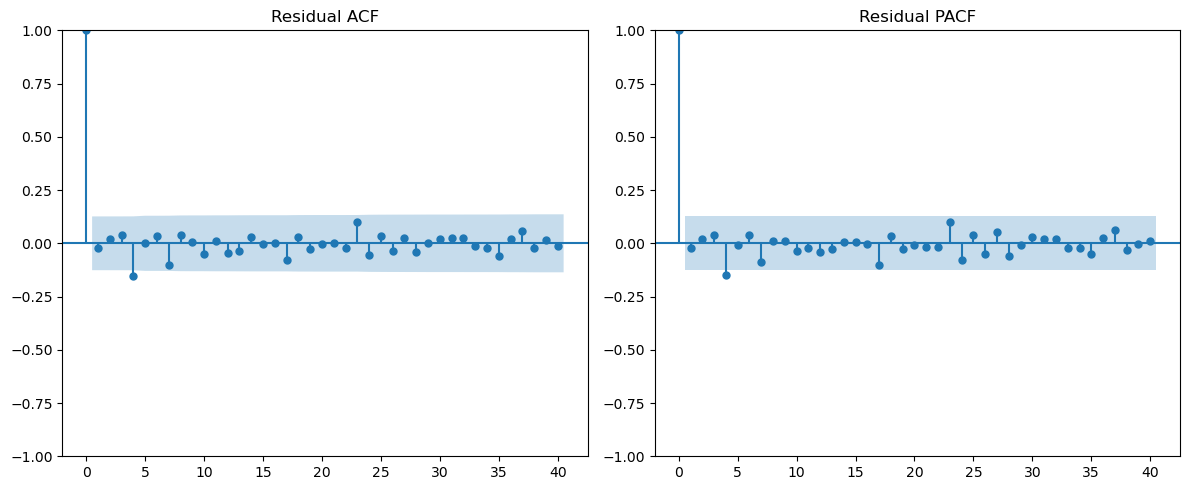

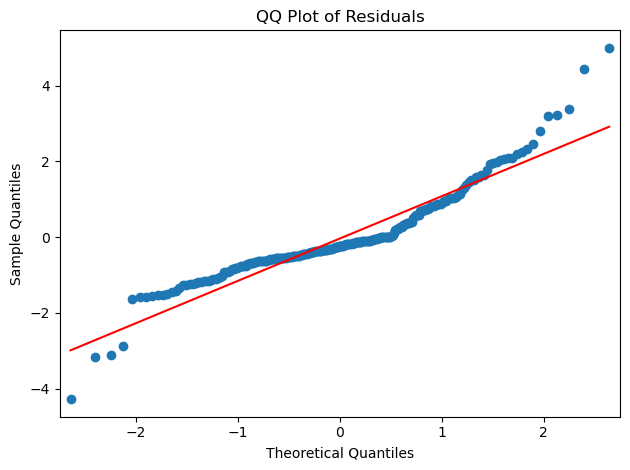

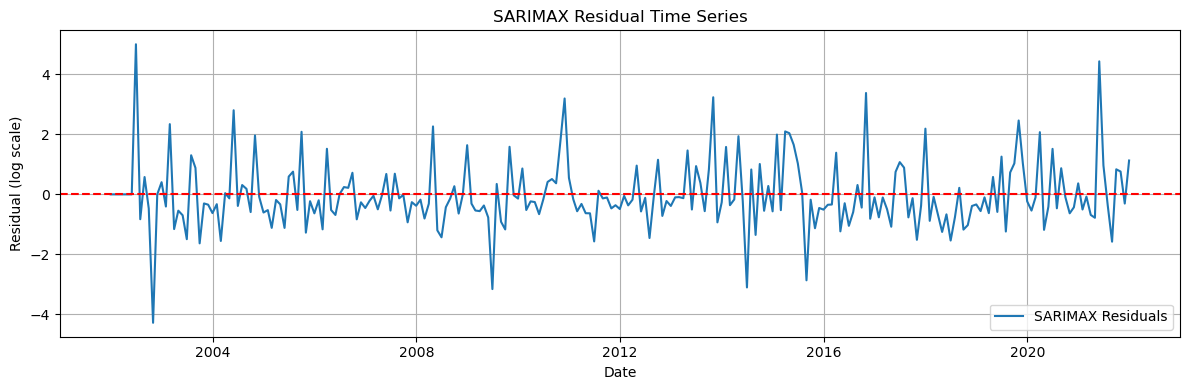

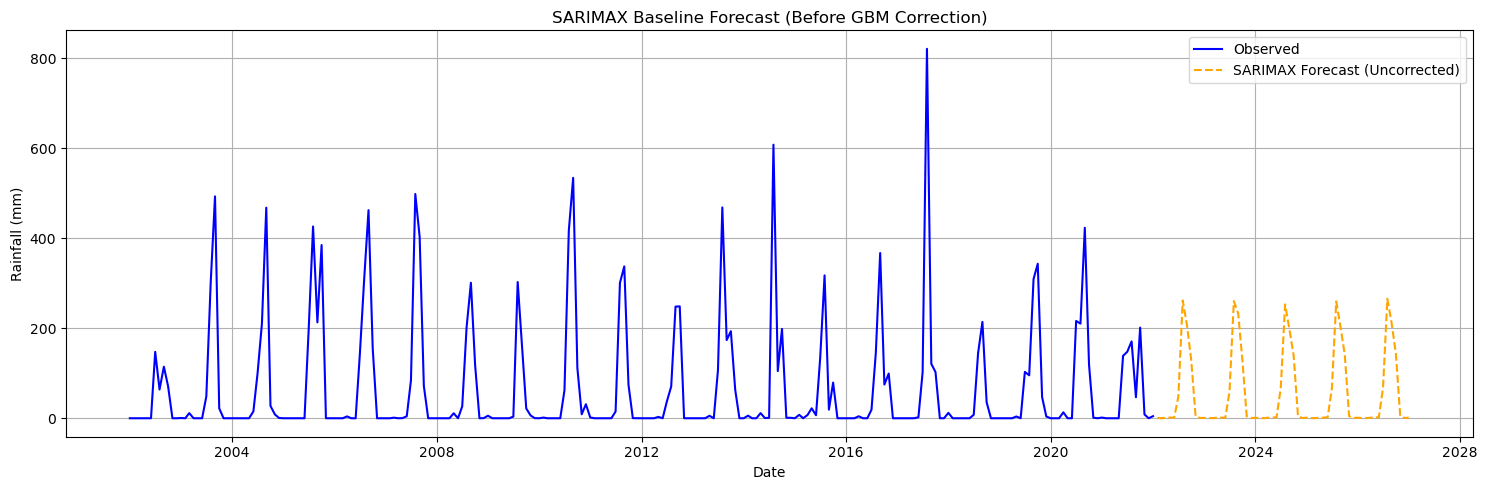

<Figure size 1000x500 with 0 Axes>

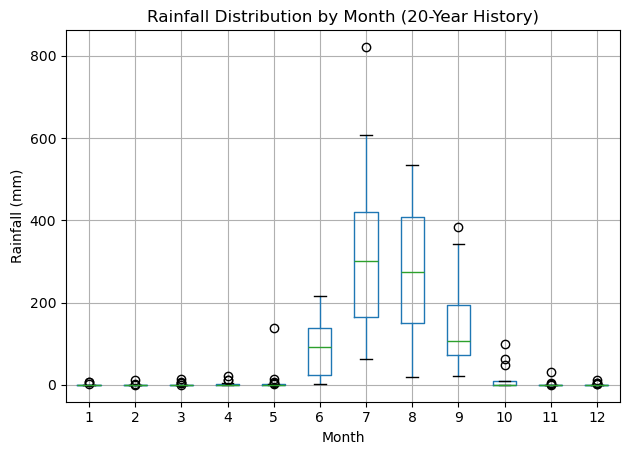

Residual RMSE: 1.2436483721853577
Residual R²: -0.2908288766284546
Final RMSE: 1.2436483721853577
Final R²: 0.7117549050086791


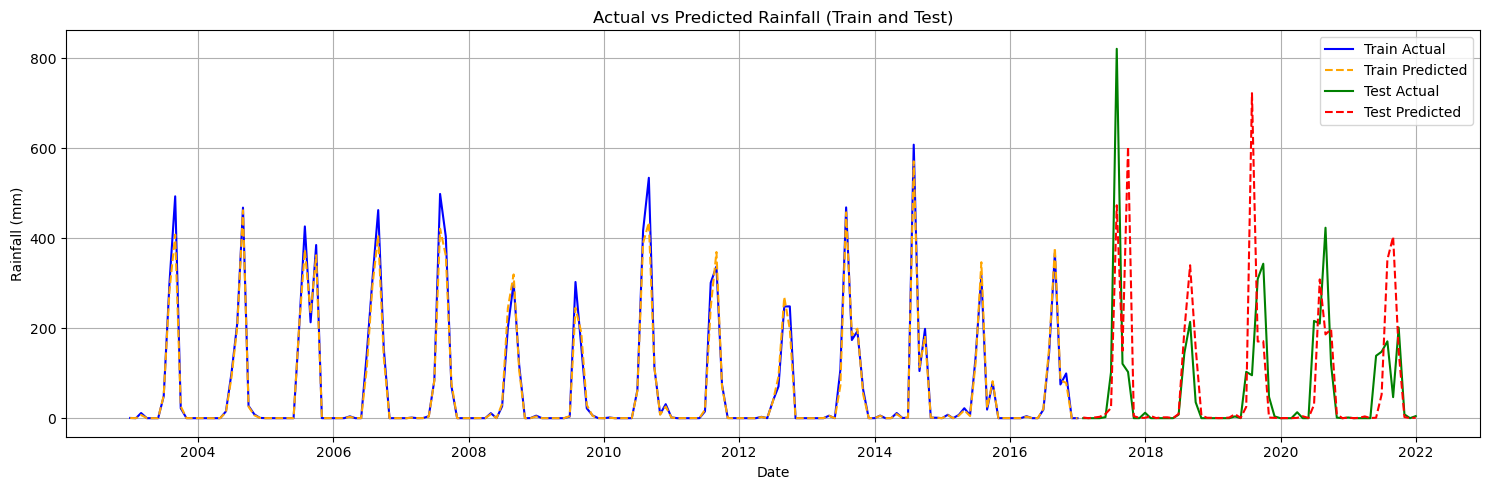

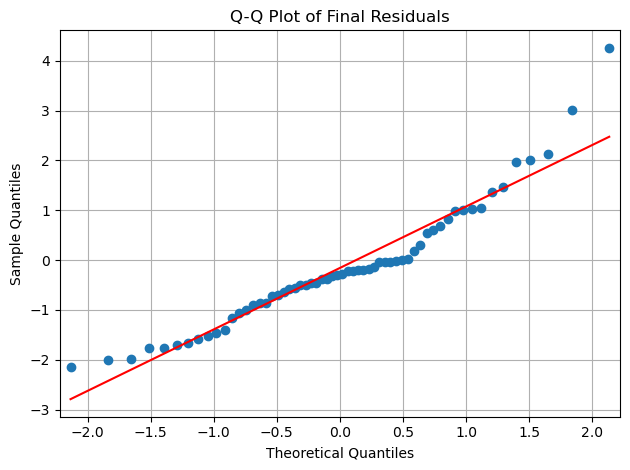

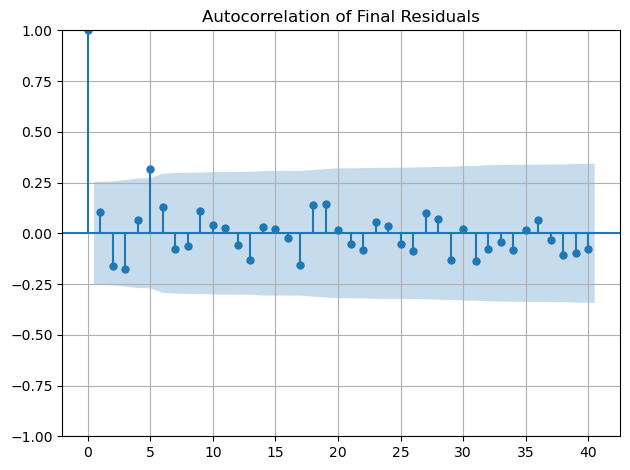

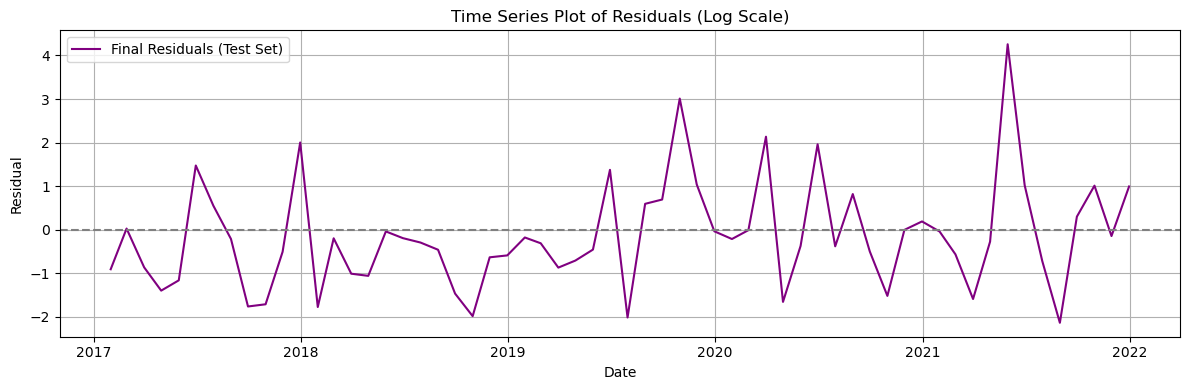

<Figure size 600x500 with 0 Axes>

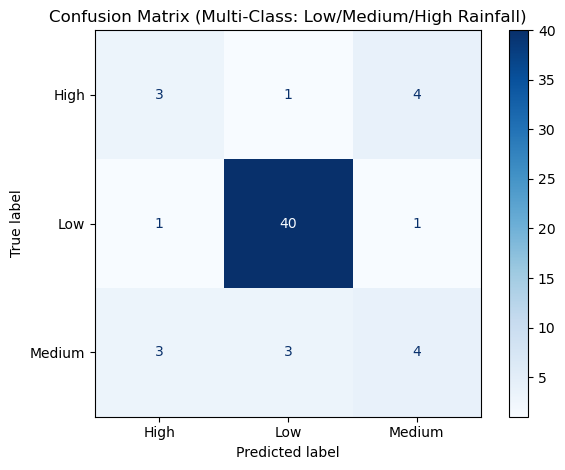

🔍 Classification Report:
              precision    recall  f1-score   support

        High       0.43      0.38      0.40         8
         Low       0.91      0.95      0.93        42
      Medium       0.44      0.40      0.42        10

    accuracy                           0.78        60
   macro avg       0.59      0.58      0.58        60
weighted avg       0.77      0.78      0.77        60


✅ SMOTE applied — Class distribution after balancing: [42 42 42]


C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\1625670286.py:272: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start=monthly_df.index[-1] + pd.DateOffset(months=1), periods=future_months, freq='M')



📊 Historical 10-Year Seasonal Rainfall:
Season  Monsoon  Post-Monsoon  Pre-Monsoon  Winter
Year                                              
2011        NaN           0.0          NaN     NaN
2012      604.6           0.0          3.0     0.0
2013      943.2          63.3          5.5     0.2
2014      912.2           2.1         11.8     5.8
2015      551.3           0.0         35.9     7.6
2016      606.9          99.4          4.4     0.0
2017     1146.7          12.0          2.2     0.0
2018      401.8           0.0          0.0     0.0
2019      851.1          51.1          3.9     0.0
2020      969.3           2.7         13.2     0.0
2021      566.7          13.0        138.7     0.0


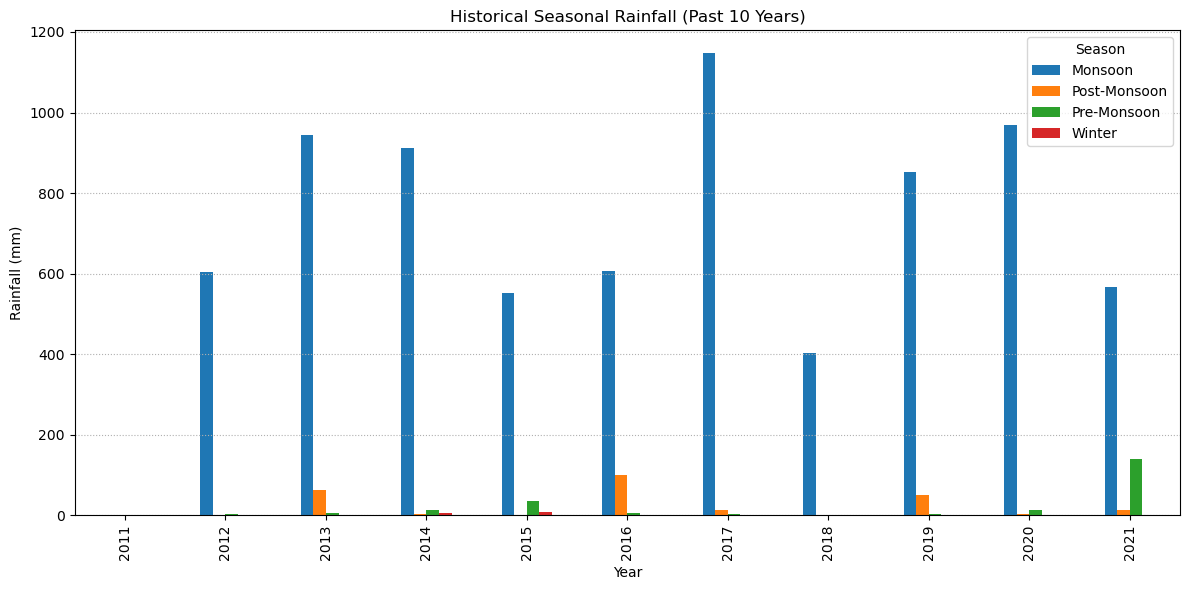


📊 5-Year Seasonal Rainfall Forecast (in mm):
Season  Monsoon  Post-Monsoon  Pre-Monsoon  Winter
Year                                              
2022     767.14        222.68         4.46    1.88
2023     629.68        169.38         5.93    2.50
2024     639.19        161.11         3.56    2.28
2025     575.92        149.30         6.11    2.61
2026     672.04        169.72         5.90    2.69


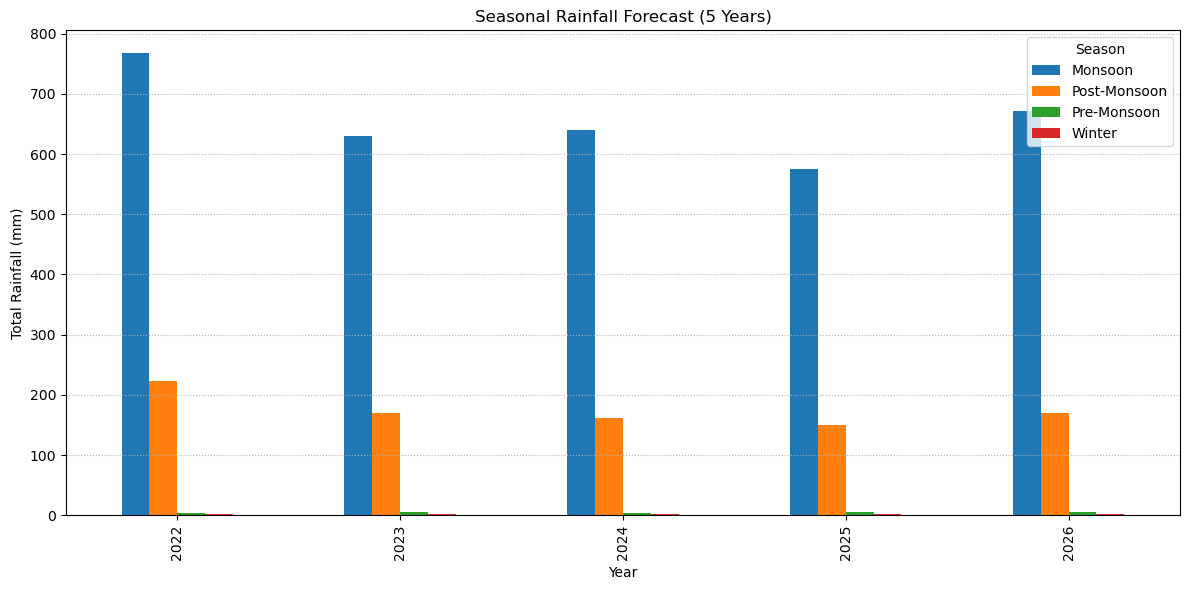

C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\1625670286.py:432: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  observed_yearly = monthly_df['..R/F'].resample('Y').sum()
C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\1625670286.py:433: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecasted_yearly = forecast_series.resample('Y').sum()


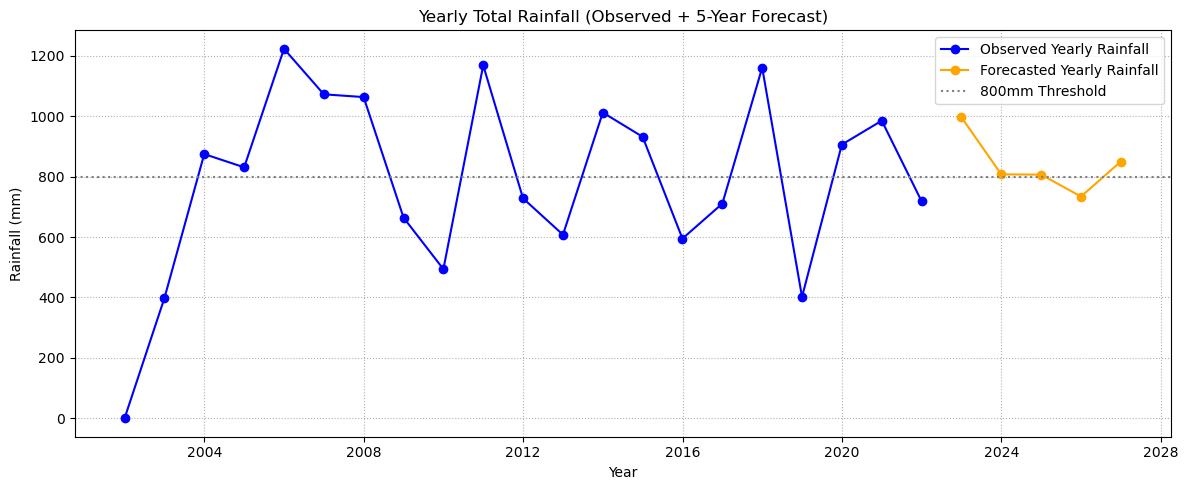

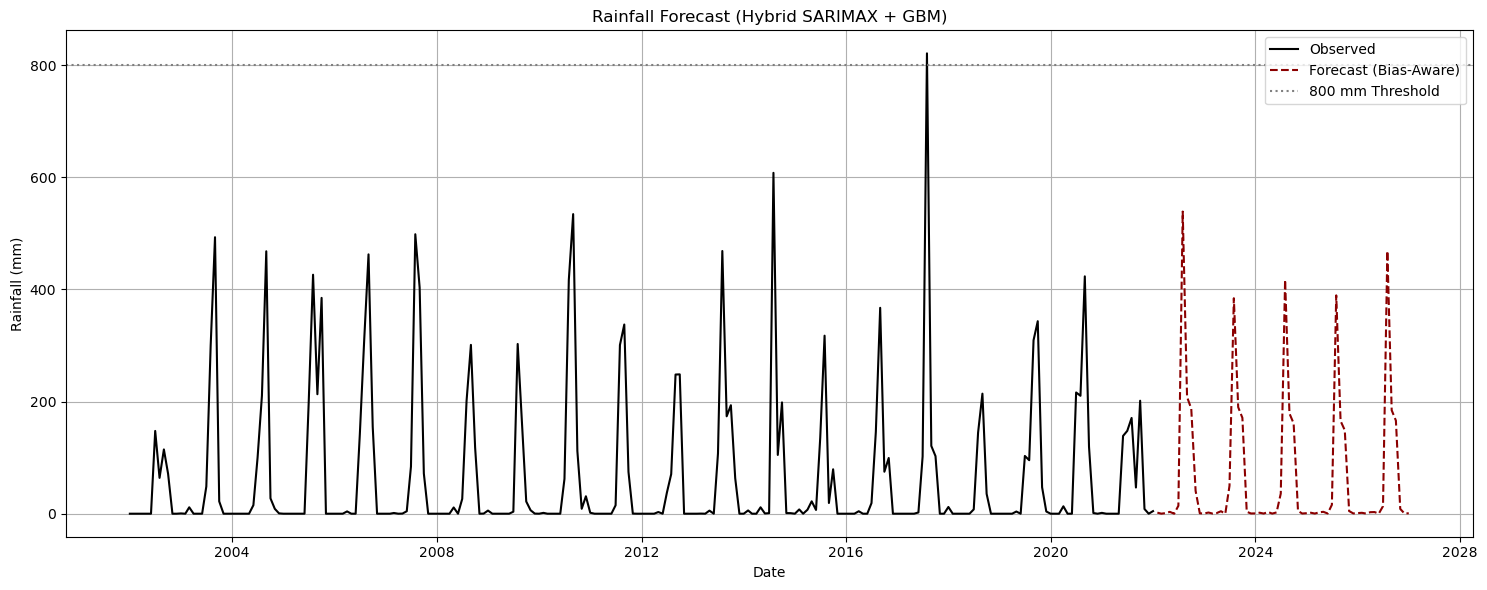

Year-wise forecast std dev (should not be near zero):
2022    161.764656
2023    121.051503
2024    127.552153
2025    119.294805
2026    141.810849
dtype: float64


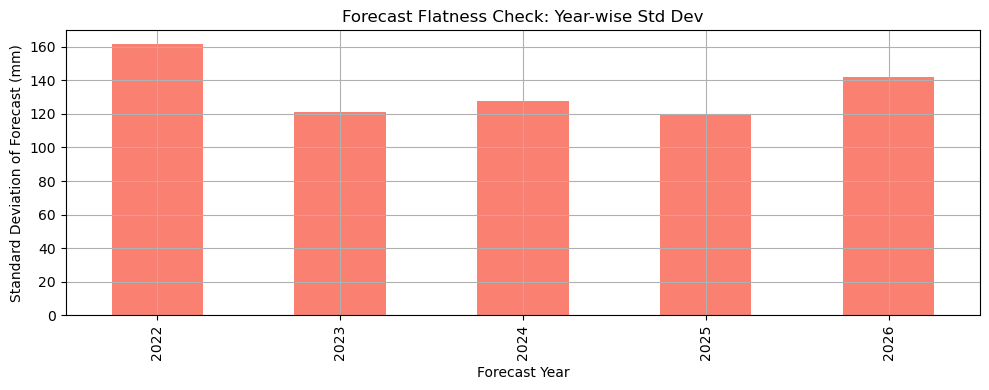

C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\1625670286.py:485: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_avg_forecast.index, y=monthly_avg_forecast.values, palette='crest')


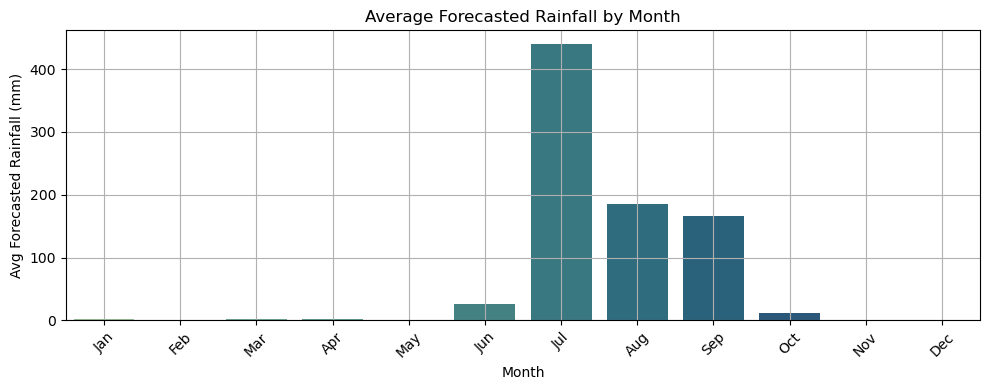


📊 Month Ranking (Forecasted Avg Rainfall):
7     439.62
8     185.38
9     166.84
6      25.85
10     12.48
4       2.85
3       2.08
1       1.81
12      0.75
5       0.57
11      0.48
2       0.25
dtype: float64


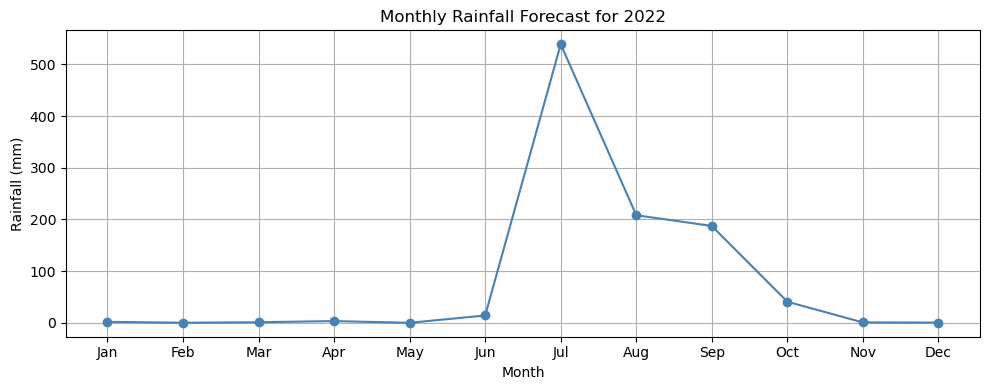

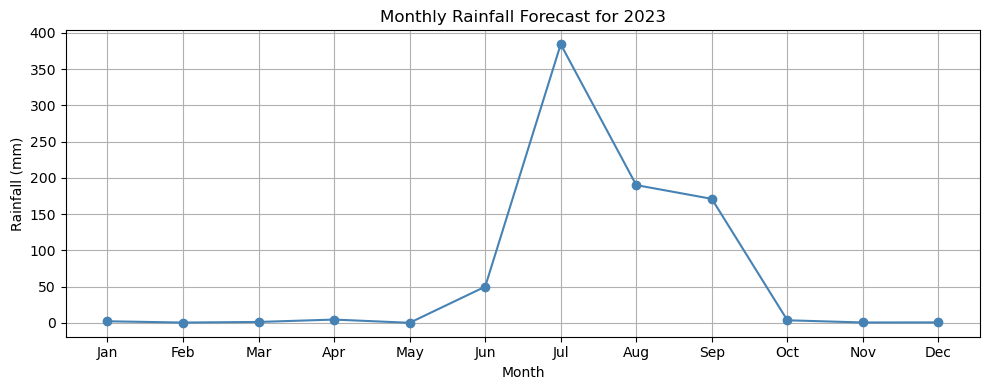

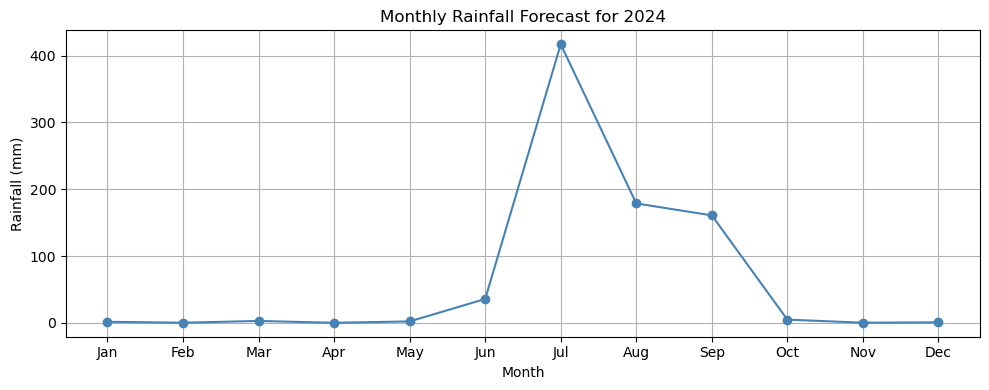

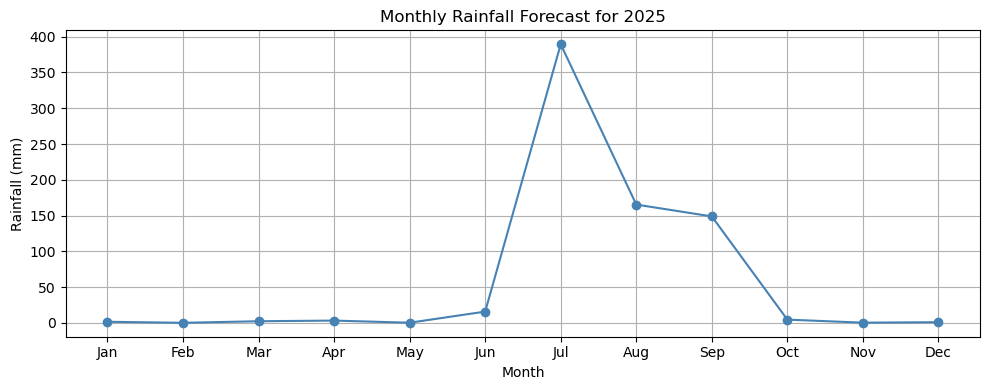

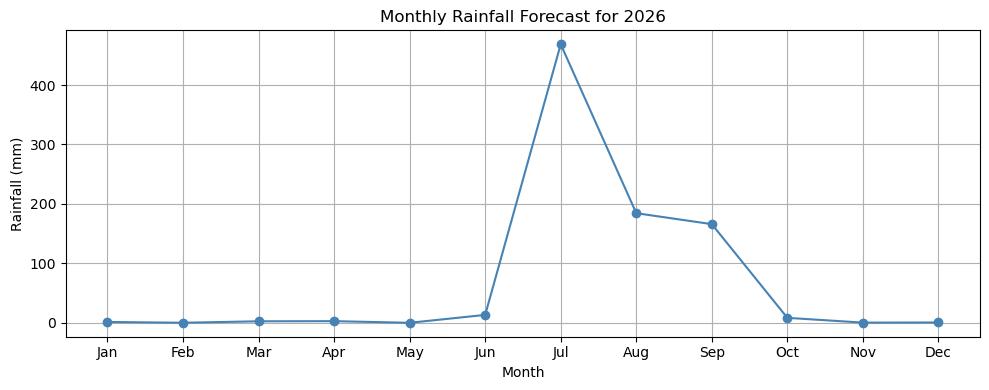


📅 Forecasted Monthly Rainfall (Formatted Table View):

Month and Year  Prediction (mm) Month and Year   Prediction (mm)  Month and Year    Prediction (mm)  
      Jan 2022              1.9        Feb 2022               0.1         Mar 2022                1.1
      Apr 2022              3.3        May 2022               0.0         Jun 2022               14.2
      Jul 2022            538.8        Aug 2022             208.1         Sep 2022              187.3
      Oct 2022             40.8        Nov 2022               0.7         Dec 2022                0.4
      Jan 2023              2.1        Feb 2023               0.3         Mar 2023                1.2
      Apr 2023              4.4        May 2023               0.0         Jun 2023               49.8
      Jul 2023            384.3        Aug 2023             190.0         Sep 2023              171.0
      Oct 2023              3.5        Nov 2023               0.4         Dec 2023                0.5
      Jan 2024            

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Data Preprocessing
# -----------------------------
monthly_df = data['..R/F'].resample('M').sum().to_frame()
monthly_df = monthly_df[monthly_df.index >= monthly_df.index[-1] - pd.DateOffset(years=20)]
monthly_df['..R/F_log'] = np.log1p(monthly_df['..R/F'])

monthwise_avg = monthly_df['..R/F_log'].groupby(monthly_df.index.month).mean()

# -----------------------------
# Fit SARIMAX
# -----------------------------
sarimax_model = SARIMAX(monthly_df['..R/F_log'], order=(2,1,2), seasonal_order=(2,1,1,12))
sarimax_result = sarimax_model.fit(disp=False)
sarimax_fitted = sarimax_result.fittedvalues
residuals = monthly_df['..R/F_log'] - sarimax_fitted
residuals = residuals.dropna()

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats
import statsmodels.api as sm

# ACF and PACF of residuals
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(residuals, ax=plt.gca(), lags=40, title="Residual ACF")
plt.subplot(1, 2, 2)
plot_pacf(residuals, ax=plt.gca(), lags=40, title="Residual PACF", method='ywm')
plt.tight_layout()
plt.show()

# QQ Plot of residuals
sm.qqplot(residuals, line='s')
plt.title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

# Residual time series plot
plt.figure(figsize=(12, 4))
plt.plot(residuals, label='SARIMAX Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title("SARIMAX Residual Time Series")
plt.xlabel("Date")
plt.ylabel("Residual (log scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Flat forecast from SARIMAX (baseline) for visual justification
forecast_baseline = sarimax_result.get_forecast(steps=60).predicted_mean
plt.figure(figsize=(15, 5))
plt.plot(monthly_df.index, monthly_df['..R/F'], label='Observed', color='blue')
plt.plot(forecast_baseline.index, np.expm1(forecast_baseline), label='SARIMAX Forecast (Uncorrected)', color='orange', linestyle='--')
plt.title("SARIMAX Baseline Forecast (Before GBM Correction)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Boxplot of rainfall by month (for spike learning justification)
monthly_df['Month'] = monthly_df.index.month
plt.figure(figsize=(10, 5))
monthly_df.boxplot(column='..R/F', by='Month')
plt.title("Rainfall Distribution by Month (20-Year History)")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()


# -----------------------------
# Define spike bias (manually prioritized)
# -----------------------------
spike_bias = {6: 0.6, 7: 1.0, 8: 0.95, 9: 0.5}
default_bias = 0.2

# -----------------------------
# Feature Engineering
# -----------------------------
def create_rf_features(df, target_col, resid=None):
    df_feat = df.copy()
    for i in range(1, 7):
        df_feat[f'lag_{i}'] = df_feat[target_col].shift(i)
    df_feat['roll_3'] = df_feat[target_col].rolling(3).mean().shift(1)
    df_feat['roll_6'] = df_feat[target_col].rolling(6).mean().shift(1)
    df_feat['month'] = df_feat.index.month
    df_feat['year'] = df_feat.index.year
    df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
    df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)
    df_feat['is_rain_month'] = df_feat['month'].isin([6, 7, 8, 9, 10]).astype(int)
    df_feat['spike_priority_score'] = df_feat['month'].map(lambda x: spike_bias.get(x, default_bias))
    df_feat['seasonal_avg'] = df_feat['month'].map(monthwise_avg)
    df_feat['is_august_boost'] = ((df_feat['month'] == 8) & (df_feat['lag_1'] > df_feat['roll_3'])).astype(int)
    df_feat['resid_lag_12'] = resid.shift(12) if resid is not None else np.nan
    return df_feat.dropna()

rf_features = create_rf_features(monthly_df[['..R/F_log']], '..R/F_log', resid=residuals)
rf_features['residual'] = residuals
rf_features.drop(columns=['..R/F_log'], inplace=True)

# -----------------------------
# Train-Test Split
# -----------------------------
cutoff = monthly_df.index[-1] - pd.DateOffset(years=5)
train_rf = rf_features[rf_features.index <= cutoff]
test_rf = rf_features[rf_features.index > cutoff]

# -----------------------------
# Train GBM
# -----------------------------
gbm = GradientBoostingRegressor(
    n_estimators=350,
    max_depth=5,
    learning_rate=0.025,
    subsample=0.8,
    loss='squared_error',
    random_state=42
)
gbm.fit(train_rf.drop(['residual'], axis=1), train_rf['residual'])

# -----------------------------
# Evaluation
# -----------------------------
residual_preds = gbm.predict(test_rf.drop(['residual'], axis=1))
true_residuals = test_rf['residual']
print("Residual RMSE:", np.sqrt(mean_squared_error(true_residuals, residual_preds)))
print("Residual R²:", r2_score(true_residuals, residual_preds))

sarimax_test_pred = sarimax_fitted[test_rf.index]
final_log_pred = sarimax_test_pred + residual_preds
final_log_actual = monthly_df['..R/F_log'].loc[test_rf.index]
print("Final RMSE:", np.sqrt(mean_squared_error(final_log_actual, final_log_pred)))
print("Final R²:", r2_score(final_log_actual, final_log_pred))

# -----------------------------
# Train vs Test Actual vs Predicted (in log scale)
# -----------------------------
train_preds = gbm.predict(train_rf.drop(['residual'], axis=1))
train_sarimax = sarimax_fitted[train_rf.index]
final_train_pred_log = train_sarimax + train_preds
final_train_actual_log = monthly_df['..R/F_log'].loc[train_rf.index]

plt.figure(figsize=(15, 5))
plt.plot(train_rf.index, np.expm1(final_train_actual_log), label='Train Actual', color='blue')
plt.plot(train_rf.index, np.expm1(final_train_pred_log), label='Train Predicted', color='orange', linestyle='--')
plt.plot(test_rf.index, np.expm1(final_log_actual), label='Test Actual', color='green')
plt.plot(test_rf.index, np.expm1(final_log_pred), label='Test Predicted', color='red', linestyle='--')
plt.title("Actual vs Predicted Rainfall (Train and Test)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Assuming final_log_pred and final_log_actual are available
final_residuals = final_log_actual - final_log_pred

#  Q-Q Plot 
sm.qqplot(final_residuals, line='s')
plt.title("Q-Q Plot of Final Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()

#  ACF Plot 
plot_acf(final_residuals, lags=40)
plt.title("Autocorrelation of Final Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()

#  Residual Time Series Plot 
plt.figure(figsize=(12, 4))
plt.plot(final_residuals, label="Final Residuals (Test Set)", color='purple')
plt.axhline(0, linestyle='--', color='gray')
plt.title("Time Series Plot of Residuals (Log Scale)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

final_mm_pred = np.expm1(final_log_pred)
final_mm_actual = np.expm1(final_log_actual)


# -----------------------------
# Classification Labels
# -----------------------------
def categorize_rain(mm):
    if mm <= 50:
        return 'Low'
    elif mm <= 200:
        return 'Medium'
    else:
        return 'High'

actual_classes = final_mm_actual.apply(categorize_rain)
predicted_classes = final_mm_pred.apply(categorize_rain)

# -----------------------------
# Label Encoding for Confusion Matrix & SMOTE
# -----------------------------
le = LabelEncoder()
y_true = le.fit_transform(actual_classes)
y_pred = le.transform(predicted_classes)

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

plt.figure(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix (Multi-Class: Low/Medium/High Rainfall)")
plt.grid(False)
plt.tight_layout()
plt.show()

# -----------------------------
# Classification Report
# -----------------------------
print("🔍 Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))


rf_clf_df = test_rf.copy()
rf_clf_df['rain_class'] = final_mm_actual.apply(categorize_rain)
X = rf_clf_df.drop(['residual', 'rain_class'], axis=1)
y = rf_clf_df['rain_class']

X_encoded = pd.get_dummies(X)  # In case of any categorical features
le_class = LabelEncoder()
y_encoded = le_class.fit_transform(y)

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_encoded, y_encoded)

print(f"\n✅ SMOTE applied — Class distribution after balancing: {np.bincount(y_resampled)}")

# -----------------------------
# Forecasting
# -----------------------------
future_months = 60
forecast_dates = pd.date_range(start=monthly_df.index[-1] + pd.DateOffset(months=1), periods=future_months, freq='M')
sarimax_baseline = sarimax_result.get_forecast(steps=future_months).predicted_mean
sarimax_baseline.index = forecast_dates

history_df = monthly_df.copy()
combined_forecast = []
feature_cols = train_rf.drop(['residual'], axis=1).columns.tolist()
prev_august_val = 0

prev_july_val = None
prev_august_val = None

for date in forecast_dates:
    lags = history_df['..R/F_log'].iloc[-6:].values[::-1]
    roll_3 = history_df['..R/F_log'].iloc[-3:].mean()
    roll_6 = history_df['..R/F_log'].iloc[-6:].mean()
    month = date.month
    year = date.year
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)
    spike_priority_score = spike_bias.get(month, default_bias)
    seasonal_avg = monthwise_avg.get(month, 0)
    resid_lag_12 = residuals.shift(12).iloc[-1] if len(residuals) >= 12 else 0
    is_rain_month = int(month in [6, 7, 8, 9, 10])
    is_august_boost = int((month == 8) and (lags[0] > roll_3))

    rf_input = {f'lag_{i+1}': lags[i] for i in range(6)}
    rf_input.update({
        'roll_3': roll_3,
        'roll_6': roll_6,
        'month': month,
        'year': year,
        'month_sin': month_sin,
        'month_cos': month_cos,
        'spike_priority_score': spike_priority_score,
        'seasonal_avg': seasonal_avg,
        'resid_lag_12': resid_lag_12,
        'is_rain_month': is_rain_month,
        'is_august_boost': is_august_boost
    })

    rf_input_df = pd.DataFrame([rf_input], index=[date])
    rf_input_df = rf_input_df[feature_cols]
    correction = gbm.predict(rf_input_df)[0]

    if month in [6, 8] and roll_3 > roll_6:
        correction += np.random.normal(0.005, 0.01)


    corrected_log = sarimax_baseline.loc[date] + correction
    corrected = max(0, np.expm1(corrected_log))

  
    if month == 8 and prev_july_val is not None:
        min_august = prev_july_val * 0.5 
        if corrected < min_august:
            corrected = (corrected + min_august) / 2



    if month == 9 and prev_august_val is not None:
        max_sept = prev_august_val * 0.9
        corrected = min(corrected, max_sept)
    if month == 9 and prev_july_val is not None:
        corrected = min(corrected, prev_july_val * 0.75)


    # Save for next-month logic
    if month == 7:
        prev_july_val = corrected
    if month == 8:
        prev_august_val = corrected

    combined_forecast.append(corrected)
    history_df.loc[date] = np.nan
    history_df.loc[date, '..R/F_log'] = np.log1p(corrected)



forecast_series = pd.Series(combined_forecast, index=forecast_dates)

# Historical 10-Year Seasonal Aggregation 
def label_season(month):
    if month in [3, 4, 5]:
        return 'Pre-Monsoon'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    elif month in [10, 11, 12]:
        return 'Post-Monsoon'
    else:
        return 'Winter'

# Create daily historical rainfall from original data
daily_data = data['..R/F'].copy()
daily_data = daily_data[daily_data.index >= daily_data.index[-1] - pd.DateOffset(years=10)]
daily_df_hist = pd.DataFrame({'Rainfall': daily_data})
daily_df_hist['Season'] = daily_df_hist.index.month.map(label_season)
daily_df_hist['Year'] = daily_df_hist.index.year

# Group by year and season
seasonal_hist = daily_df_hist.groupby(['Year', 'Season'])['Rainfall'].sum().unstack()
print("\n📊 Historical 10-Year Seasonal Rainfall:")
print(seasonal_hist.round(2))

# Plot historical seasonal totals
seasonal_hist.plot(kind='bar', figsize=(12, 6), title="Historical Seasonal Rainfall (Past 10 Years)")
plt.ylabel("Rainfall (mm)")
plt.grid(axis='y', linestyle=':')
plt.tight_layout()
plt.show()


# Daily Forecast Expansion and Seasonal Aggregation 

# Step 1: Upsample monthly forecast to daily 
daily_forecast = forecast_series.resample('D').ffill()
days_in_month = daily_forecast.index.daysinmonth
daily_forecast /= days_in_month

# Step 2: Define function to classify season
def label_season(month):
    if month in [3, 4, 5]:
        return 'Pre-Monsoon'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    elif month in [10, 11, 12]:
        return 'Post-Monsoon'
    else:
        return 'Winter'

# Step 3: Create a DataFrame for season tagging
daily_df = pd.DataFrame({'Rainfall': daily_forecast})
daily_df['Season'] = daily_df.index.month.map(label_season)
daily_df['Year'] = daily_df.index.year

# Step 4: Aggregate seasonal totals per year
seasonal_totals = daily_df.groupby(['Year', 'Season'])['Rainfall'].sum().unstack()

# Step 5: Display or plot the results
print("\n📊 5-Year Seasonal Rainfall Forecast (in mm):")
print(seasonal_totals.round(2))

seasonal_totals.plot(kind='bar', figsize=(12, 6), title="Seasonal Rainfall Forecast (5 Years)")
plt.ylabel("Total Rainfall (mm)")
plt.grid(axis='y', linestyle=':')
plt.tight_layout()
plt.show()


# Split observed and forecasted portions
last_obs_year = monthly_df.index[-1].year
forecast_years = forecast_series.index.year.unique()

# Compute yearly rainfall
observed_yearly = monthly_df['..R/F'].resample('Y').sum()
forecasted_yearly = forecast_series.resample('Y').sum()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(observed_yearly.index, observed_yearly.values, label='Observed Yearly Rainfall', color='blue', marker='o')
plt.plot(forecasted_yearly.index, forecasted_yearly.values, label='Forecasted Yearly Rainfall', color='orange', marker='o')
plt.axhline(800, color='gray', linestyle=':', label='800mm Threshold')
plt.title("Yearly Total Rainfall (Observed + 5-Year Forecast)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

# -----------------------------
# Plot Main Forecast
# -----------------------------
plt.figure(figsize=(15, 6))
plt.plot(monthly_df.index, monthly_df['..R/F'], label='Observed', color='black')
plt.plot(forecast_series.index, forecast_series, label='Forecast (Bias-Aware)', color='darkred', linestyle='--')
plt.axhline(800, color='gray', linestyle=':', label='800 mm Threshold')
plt.title("Rainfall Forecast (Hybrid SARIMAX + GBM)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# Check Flatness (Std Dev year-wise) ---
forecast_yearly_std = forecast_series.groupby(forecast_series.index.year).std()
print("Year-wise forecast std dev (should not be near zero):")
print(forecast_yearly_std)

plt.figure(figsize=(10, 4))
forecast_yearly_std.plot(kind='bar', color='salmon')
plt.title("Forecast Flatness Check: Year-wise Std Dev")
plt.ylabel("Standard Deviation of Forecast (mm)")
plt.xlabel("Forecast Year")
plt.grid(True)
plt.tight_layout()
plt.show()

#Month-wise Peak Alignment
import seaborn as sns

monthly_avg_forecast = forecast_series.groupby(forecast_series.index.month).mean()

plt.figure(figsize=(10, 4))
sns.barplot(x=monthly_avg_forecast.index, y=monthly_avg_forecast.values, palette='crest')
plt.title("Average Forecasted Rainfall by Month")
plt.xlabel("Month")
plt.ylabel("Avg Forecasted Rainfall (mm)")
plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


print("\n📊 Month Ranking (Forecasted Avg Rainfall):")
print(monthly_avg_forecast.sort_values(ascending=False).round(2))


# -----------------------------
# Plot Year-Wise Monthly Forecasts
# -----------------------------
for year in forecast_series.index.year.unique():
    subset = forecast_series[forecast_series.index.year == year]
    plt.figure(figsize=(10, 4))
    plt.plot(subset.index.month, subset.values, marker='o', color='steelblue')
    plt.title(f"Monthly Rainfall Forecast for {year}")
    plt.xlabel("Month")
    plt.ylabel("Rainfall (mm)")
    plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Create a DataFrame with forecast dates and rainfall
forecast_table = pd.DataFrame({
    'Month and Year': forecast_series.index.strftime('%b %Y'),
    'Prediction (mm)': forecast_series.round(1)
})

# Reset index for better formatting
forecast_table = forecast_table.reset_index(drop=True)

chunks = [forecast_table[i::3].reset_index(drop=True) for i in range(3)]
side_by_side = pd.concat(chunks, axis=1)

# Rename columns
side_by_side.columns = [
    'Month and Year', 'Prediction (mm)',
    'Month and Year ', 'Prediction (mm) ',
    'Month and Year  ', 'Prediction (mm)  '
]

# Display as formatted table
print("\n📅 Forecasted Monthly Rainfall (Formatted Table View):\n")
print(side_by_side.to_string(index=False))


C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\4069138526.py:11: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\suhan\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


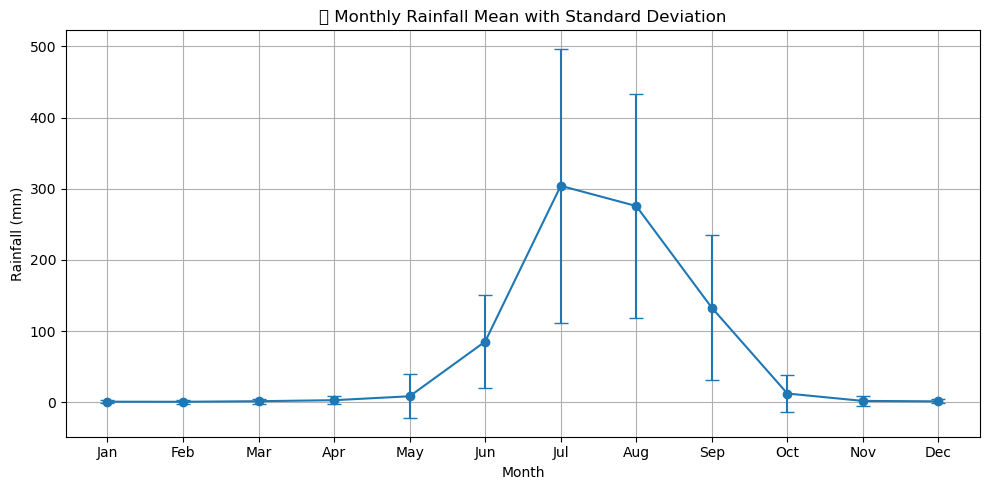

In [6]:
monthly_df['Month'] = monthly_df.index.month
monthly_stats = monthly_df.groupby('Month')['..R/F'].agg(['mean', 'std'])

plt.figure(figsize=(10, 5))
plt.errorbar(monthly_stats.index, monthly_stats['mean'], yerr=monthly_stats['std'], fmt='-o', capsize=5)
plt.title("📊 Monthly Rainfall Mean with Standard Deviation")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.grid(True)
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()


C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\1930939881.py:20: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\suhan\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


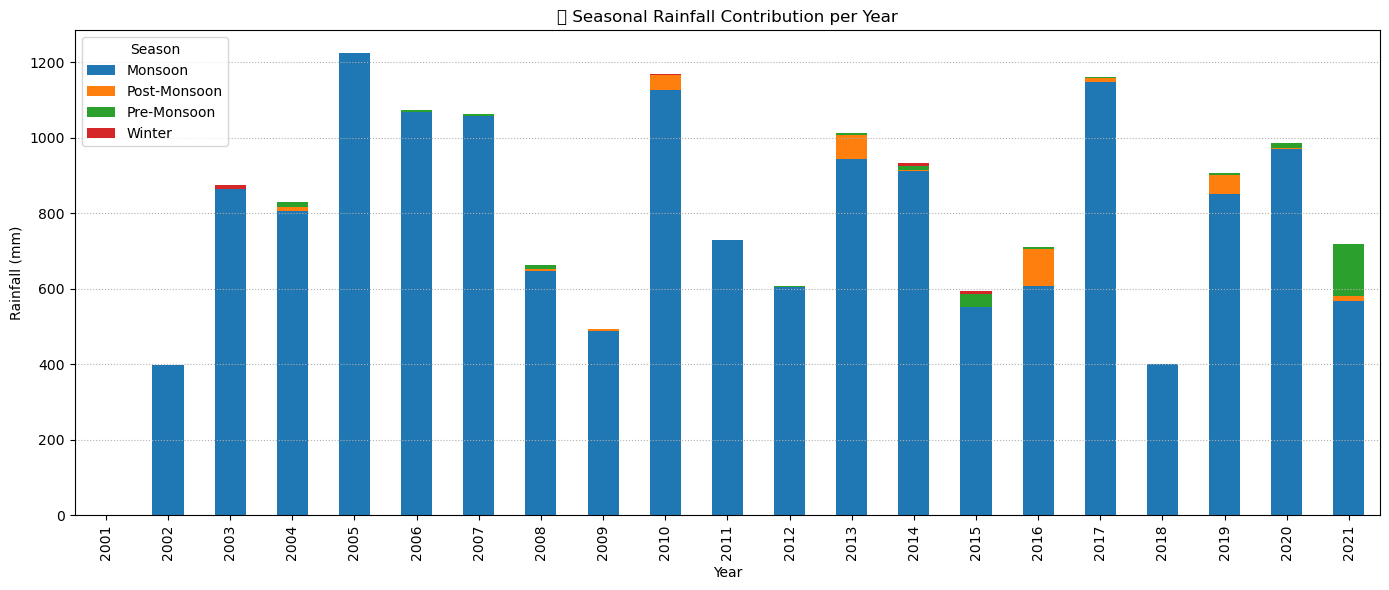

In [7]:
def label_season(month):
    if month in [3, 4, 5]:
        return 'Pre-Monsoon'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    elif month in [10, 11, 12]:
        return 'Post-Monsoon'
    else:
        return 'Winter'

monthly_df['Season'] = monthly_df['Month'].map(label_season)
monthly_df['Year'] = monthly_df.index.year
seasonal_df = monthly_df.groupby(['Year', 'Season'])['..R/F'].sum().unstack()

# Plot seasonal variation over years
seasonal_df.plot(kind='bar', stacked=True, figsize=(14,6))
plt.title("🌧️ Seasonal Rainfall Contribution per Year")
plt.ylabel("Rainfall (mm)")
plt.grid(axis='y', linestyle=':')
plt.tight_layout()
plt.show()


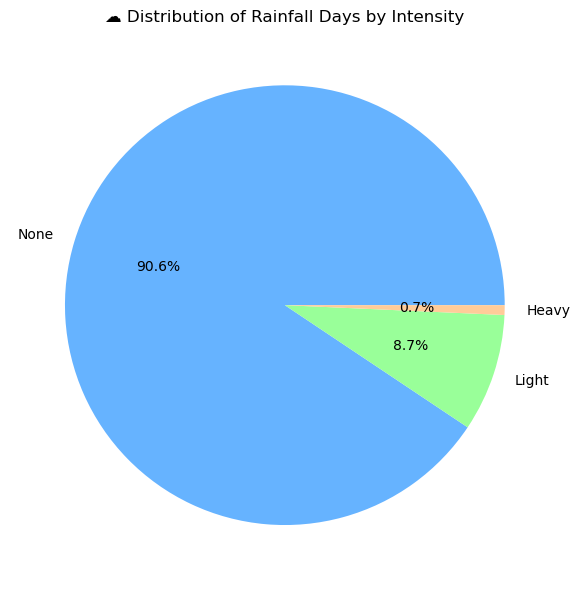

In [8]:
def classify_rain(mm):
    if mm >= 64.5:
        return 'Heavy'
    elif mm >= 2.5:
        return 'Light'
    else:
        return 'None'

daily_df = data[['..R/F']].copy()
daily_df['Rain_Class'] = daily_df['..R/F'].apply(classify_rain)
class_counts = daily_df['Rain_Class'].value_counts(normalize=True) * 100

# Pie Chart
plt.figure(figsize=(6,6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ffcc99'])
plt.title("☁️ Distribution of Rainfall Days by Intensity")
plt.tight_layout()
plt.show()


C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\379921574.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_variance = monthly_df['..R/F'].resample('Y').var()
C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\379921574.py:9: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\suhan\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


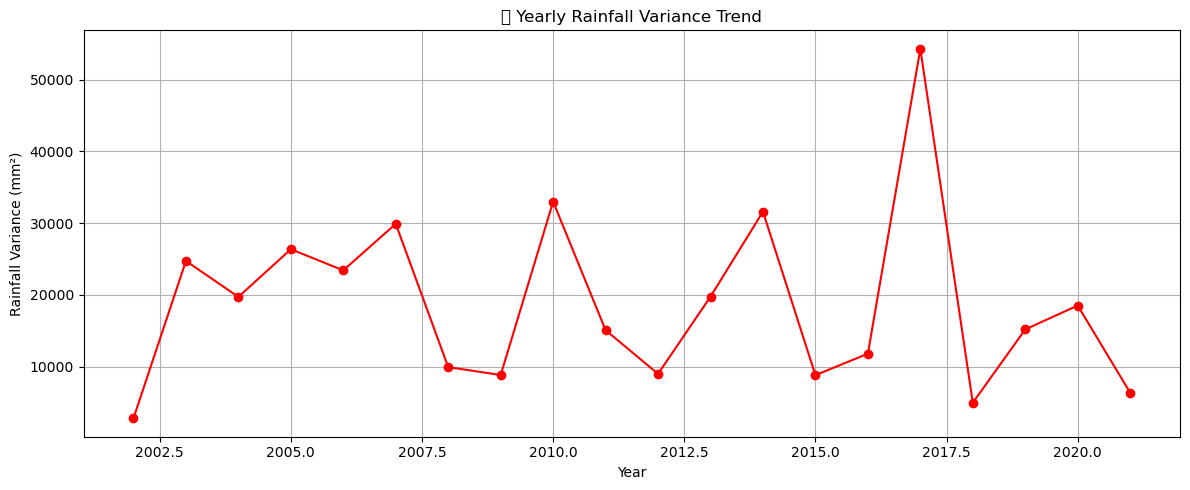

In [9]:
yearly_variance = monthly_df['..R/F'].resample('Y').var()

plt.figure(figsize=(12,5))
plt.plot(yearly_variance.index.year, yearly_variance.values, marker='o', color='red')
plt.title("📈 Yearly Rainfall Variance Trend")
plt.xlabel("Year")
plt.ylabel("Rainfall Variance (mm²)")
plt.grid(True)
plt.tight_layout()
plt.show()


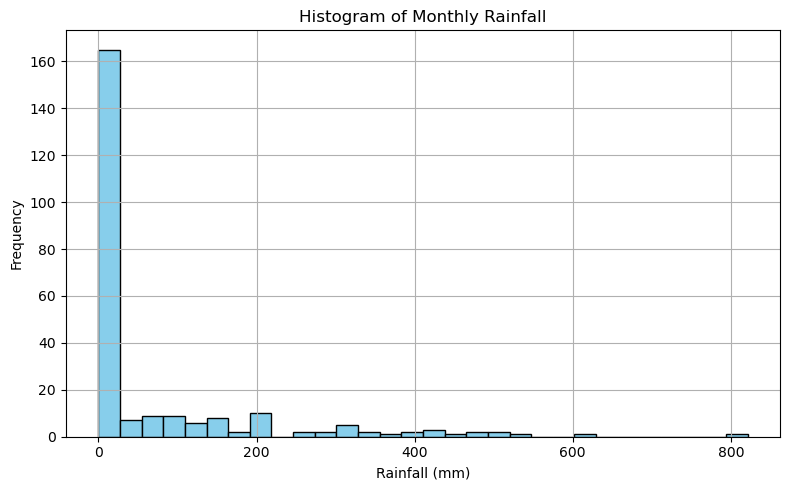

In [32]:
plt.figure(figsize=(8,5))
plt.hist(monthly_df['..R/F'], bins=30, color='skyblue', edgecolor='black')
plt.title("Histogram of Monthly Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\suhan\AppData\Local\Temp\ipykernel_31680\1487620416.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data['..R/F'].resample('M').sum().to_frame()
C:\Users\suhan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\suhan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\suhan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


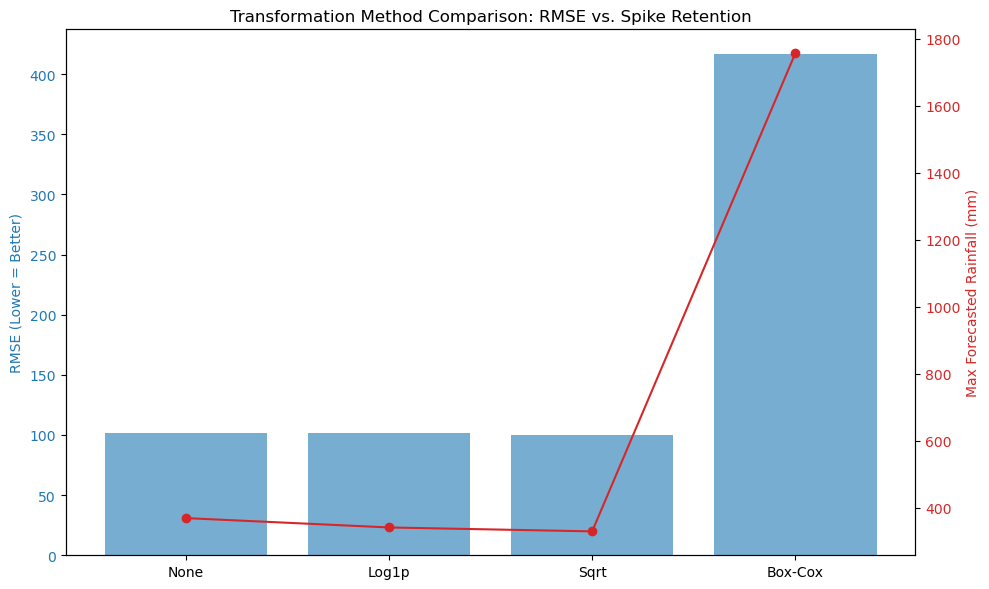

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.metrics import mean_squared_error

# Prepare monthly rainfall
monthly = data['..R/F'].resample('M').sum().to_frame()
monthly = monthly[monthly.index >= monthly.index[-1] - pd.DateOffset(years=20)]
monthly = monthly.interpolate()
original = monthly['..R/F'].copy()

# Define transformations
transformations = {
    'None': lambda x: x,
    'Log1p': np.log1p,
    'Sqrt': np.sqrt,
    'Box-Cox': lambda x: boxcox(x + 1e-6)[0]
}
inverse_transformations = {
    'None': lambda x: x,
    'Log1p': np.expm1,
    'Sqrt': lambda x: np.square(x),
    'Box-Cox': lambda x: inv_boxcox(x, fitted_lambda)
}

results = {}

for name, transform_func in transformations.items():
    try:
        transformed = transform_func(monthly['..R/F'])
        if name == 'Box-Cox':
            transformed, fitted_lambda = boxcox(monthly['..R/F'] + 1e-6)
            monthly['trans'] = transformed
        else:
            monthly['trans'] = transformed

        # Train-test split
        cutoff = monthly.index[-1] - pd.DateOffset(years=5)
        train = monthly[monthly.index <= cutoff]['trans']
        test = monthly[monthly.index > cutoff]['trans']

        # Fit SARIMAX on transformed
        model = SARIMAX(train, order=(2,1,2), seasonal_order=(2,1,1,12))
        result = model.fit(disp=False)

        forecast = result.get_forecast(steps=len(test)).predicted_mean
        inv_forecast = inverse_transformations[name](forecast)
        inv_actual = original.loc[test.index]

        rmse = np.sqrt(mean_squared_error(inv_actual, inv_forecast))
        max_forecast = inv_forecast.max()

        results[name] = {'RMSE': rmse, 'Max Forecast': max_forecast}

    except Exception as e:
        print(f"Skipped {name}: {e}")


df_results = pd.DataFrame(results).T

fig, ax1 = plt.subplots(figsize=(10, 6))

color_rmse = 'tab:blue'
color_spike = 'tab:red'

# Bar for RMSE
ax1.set_ylabel('RMSE (Lower = Better)', color=color_rmse)
ax1.bar(df_results.index, df_results['RMSE'], color=color_rmse, alpha=0.6, label='RMSE')
ax1.tick_params(axis='y', labelcolor=color_rmse)

# Twin axis for Max Forecast (Spike)
ax2 = ax1.twinx()
ax2.set_ylabel('Max Forecasted Rainfall (mm)', color=color_spike)
ax2.plot(df_results.index, df_results['Max Forecast'], color=color_spike, marker='o', label='Spike Retention')
ax2.tick_params(axis='y', labelcolor=color_spike)

# Title and layout
plt.title("Transformation Method Comparison: RMSE vs. Spike Retention")
fig.tight_layout()
plt.grid(axis='x')
plt.show()
